In [ ]:
# Autoreload custom modules
%load_ext autoreload
%autoreload 2

UsageError: Line magic function `%autoreload` not found.


In [17]:
import sys, os
import importlib

import pandas as pd
import json

import numpy as np
import jax
import jax.numpy as jnp
import optax

import time
import importlib
import matplotlib.pyplot as plt

In [ ]:
# import custom modules
sys.path.append('..')

from models.models import DecoderOnlyTransformer
from util.data_loader import load_data, encode, decode, get_batch
from util.optimization import train_step, loss_and_metrics, create_train_state

In [32]:
# initialize jax random key
master_key = jax.random.key(0)

In [ ]:
# load dataset
train_data, test_data, ctoi, itoc, vocab_size = load_data(encoded_path='../data/encoded.pkl')

#### Training loop

In [34]:
# create a basic training loop just for sanity check that the model runs
'''
niters = 100
batch_size = 16
seq_len = 128
learning_rate = 1e-3

model, params = create_train_state(key, vocab_size, 256, 4, 4, seq_len, dropout_rate=0.2)
tx = optax.adamw(learning_rate)
opt_state = tx.init(params)


for i in range(niters):
    input, target = get_batch(train_data, batch_size, seq_len)

    params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx, key=key)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new

    # Evaluate on test set every 10 iters
    if i % 10 == 0:
        B_test, T_test = 1024, 64
        test_input, test_target = get_batch(test_data, batch_size, seq_len)
        test_logits = model.apply({'params': params}, test_input, deterministic=True) # Prevent dropout during evaluation
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        print(f"Iter {i}, Train Loss: {metrics['loss']:.4f}, Test Loss: {test_loss:.4f}")
'''

'\nniters = 100\nbatch_size = 16\nseq_len = 128\nlearning_rate = 1e-3\n\nmodel, params = create_train_state(key, vocab_size, 256, 4, 4, seq_len, dropout_rate=0.2)\ntx = optax.adamw(learning_rate)\nopt_state = tx.init(params)\n\n\nfor i in range(niters):\n    input, target = get_batch(train_data, batch_size, seq_len)\n\n    params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx, key=key)\n\n    # update params and opt_state\n    params = params_new\n    opt_state = opt_state_new\n\n    # Evaluate on test set every 10 iters\n    if i % 10 == 0:\n        B_test, T_test = 1024, 64\n        test_input, test_target = get_batch(test_data, batch_size, seq_len)\n        test_logits = model.apply({\'params\': params}, test_input, deterministic=True) # Prevent dropout during evaluation\n        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)\n        print(f"Iter {i}, Train Loss: {metrics[\'loss\']:.4f}, Test Loss: {test_loss:.4f}")\n'

#### Parameters

In [70]:
# Model parameters
d_model = 256
n_heads = 4
n_layers = 4 # Based on model_arch experiment

# Training parameters
B, T = 128, 64
niter = 10000
learning_rate = 5e-4

#### Training Function

In [36]:
def train_model(dropout_rate, master_key):
    start_time = time.time()

    # Initialize model and optimizer
    master_key, init_key = jax.random.split(master_key)
    model, params = create_train_state(init_key, vocab_size, d_model, n_layers, n_heads, T, dropout_rate=dropout_rate)
    tx = optax.adamw(learning_rate) # standard AdamW optimizer
    opt_state = tx.init(params)

    loss_history = []
    time_history = []
    test_loss_history = []
    test_time_history = []

    cur_iter = 0
    while True:
        input, target = get_batch(train_data, B, T)

        # Training step
        master_key, dropout_key = jax.random.split(master_key)
        params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx, key=dropout_key)

        # uodate params and opt_state
        params = params_new
        opt_state = opt_state_new
        # get metrics
        acc = metrics['acc']
        acc_last = metrics['acc_last']
        loss = metrics['loss']

        # append to history
        loss_history.append(loss)
        time_history.append(time.time() - start_time)

        # Evaluate on test set regularly
        if cur_iter % (niter // 50) == 0 or cur_iter == niter - 1:
            time_since_start = time.time() - start_time
            B_test, T_test = 1024, 64 # larger batch size for evaluation
            test_input, test_target = get_batch(test_data, B_test, T_test)
            test_logits = model.apply({'params': params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            test_acc = test_metrics['acc']
            test_acc_last = test_metrics['acc_last']
            test_loss_history.append(test_loss)
            test_time_history.append(time_since_start)
            print(f"iteration {cur_iter:_}  time: {time_since_start:.1f} seconds")
            print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
            print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
            print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
            print()

        cur_iter += 1
        if cur_iter >= niter:
            results = {
                'Dropout': dropout_rate,
                'train_loss_history': loss_history,
                'train_time_history': time_history,
                'test_loss_history': test_loss_history,
                'test_time_history': test_time_history,
            }
            return results, master_key

In [ ]:
# sanity check
'''
results, master_key = train_model(dropout_rate=0.1, master_key=master_key)
'''

#### Dropout Training

The optimal dropout rate for many transformer models is usually `0.0-0.5`

In [38]:
# Results summary
results_summary = []

In [39]:
# Convert JAX arrays to lists
def convert_to_list(obj):
    if isinstance(obj, dict):
        return {k: convert_to_list(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_list(item) for item in obj]
    elif isinstance(obj, jax.numpy.ndarray):
        return obj.tolist() # Convert JAX array to Python list
    else:
        return obj

In [73]:
# Dropout rate = 0.0 (no dropout)
results_dropout_0, master_key = train_model(dropout_rate=0.0, master_key=master_key)
results_summary.append(results_dropout_0)

iteration 0  time: 5.5 seconds
	 	 loss(train :: test): 3.9676 :: 3.7942
	 	 accuracy (train :: test): 2.1% :: 15.3%
	 	 accuracy (last character) (train :: test): 3.1% :: 14.4%

iteration 200  time: 19.2 seconds
	 	 loss(train :: test): 2.2909 :: 2.2695
	 	 accuracy (train :: test): 30.6% :: 30.8%
	 	 accuracy (last character) (train :: test): 28.1% :: 28.8%

iteration 400  time: 33.8 seconds
	 	 loss(train :: test): 1.8092 :: 1.8465
	 	 accuracy (train :: test): 44.3% :: 43.9%
	 	 accuracy (last character) (train :: test): 38.3% :: 42.2%

iteration 600  time: 48.5 seconds
	 	 loss(train :: test): 1.6723 :: 1.6469
	 	 accuracy (train :: test): 49.1% :: 49.8%
	 	 accuracy (last character) (train :: test): 48.4% :: 47.5%

iteration 800  time: 62.9 seconds
	 	 loss(train :: test): 1.5826 :: 1.5609
	 	 accuracy (train :: test): 51.4% :: 52.2%
	 	 accuracy (last character) (train :: test): 46.9% :: 52.5%

iteration 1_000  time: 77.2 seconds
	 	 loss(train :: test): 1.4993 :: 1.5157
	 	 acc

In [74]:
# Dropout rate = 0.1
results_dropout_1, master_key = train_model(dropout_rate=0.1, master_key=master_key)
results_summary.append(results_dropout_1)

iteration 0  time: 9.8 seconds
	 	 loss(train :: test): 3.7826 :: 3.8264
	 	 accuracy (train :: test): 3.0% :: 17.1%
	 	 accuracy (last character) (train :: test): 3.9% :: 17.7%

iteration 200  time: 23.9 seconds
	 	 loss(train :: test): 2.3608 :: 2.3200
	 	 accuracy (train :: test): 27.8% :: 29.5%
	 	 accuracy (last character) (train :: test): 29.7% :: 28.2%

iteration 400  time: 39.2 seconds
	 	 loss(train :: test): 1.9640 :: 1.9031
	 	 accuracy (train :: test): 39.9% :: 41.8%
	 	 accuracy (last character) (train :: test): 40.6% :: 42.4%

iteration 600  time: 54.2 seconds
	 	 loss(train :: test): 1.7999 :: 1.7283
	 	 accuracy (train :: test): 45.3% :: 47.3%
	 	 accuracy (last character) (train :: test): 41.4% :: 46.5%

iteration 800  time: 69.0 seconds
	 	 loss(train :: test): 1.6521 :: 1.6627
	 	 accuracy (train :: test): 49.7% :: 49.1%
	 	 accuracy (last character) (train :: test): 55.5% :: 52.1%

iteration 1_000  time: 83.6 seconds
	 	 loss(train :: test): 1.6074 :: 1.5702
	 	 acc

In [75]:
# Dropout rate = 0.2
results_dropout_2, master_key = train_model(dropout_rate=0.2, master_key=master_key)
results_summary.append(results_dropout_2)

iteration 0  time: 8.6 seconds
	 	 loss(train :: test): 3.8374 :: 3.9439
	 	 accuracy (train :: test): 3.1% :: 17.1%
	 	 accuracy (last character) (train :: test): 3.9% :: 15.1%

iteration 200  time: 22.7 seconds
	 	 loss(train :: test): 2.3953 :: 2.3630
	 	 accuracy (train :: test): 27.7% :: 28.1%
	 	 accuracy (last character) (train :: test): 26.6% :: 26.2%

iteration 400  time: 37.9 seconds
	 	 loss(train :: test): 2.1766 :: 2.0921
	 	 accuracy (train :: test): 33.8% :: 36.4%
	 	 accuracy (last character) (train :: test): 35.2% :: 36.3%

iteration 600  time: 52.9 seconds
	 	 loss(train :: test): 1.9544 :: 1.9044
	 	 accuracy (train :: test): 39.8% :: 41.4%
	 	 accuracy (last character) (train :: test): 44.5% :: 38.1%

iteration 800  time: 67.6 seconds
	 	 loss(train :: test): 1.8396 :: 1.7783
	 	 accuracy (train :: test): 44.4% :: 45.9%
	 	 accuracy (last character) (train :: test): 40.6% :: 46.7%

iteration 1_000  time: 82.2 seconds
	 	 loss(train :: test): 1.7678 :: 1.7003
	 	 acc

In [76]:
# Dropout rate = 0.3
results_dropout_3, master_key = train_model(dropout_rate=0.3, master_key=master_key)
results_summary.append(results_dropout_3)

iteration 0  time: 9.8 seconds
	 	 loss(train :: test): 4.0514 :: 3.3105
	 	 accuracy (train :: test): 2.1% :: 13.5%
	 	 accuracy (last character) (train :: test): 0.8% :: 14.7%

iteration 200  time: 23.9 seconds
	 	 loss(train :: test): 2.4130 :: 2.3679
	 	 accuracy (train :: test): 26.3% :: 28.0%
	 	 accuracy (last character) (train :: test): 25.8% :: 29.1%

iteration 400  time: 39.1 seconds
	 	 loss(train :: test): 2.1878 :: 2.1167
	 	 accuracy (train :: test): 33.2% :: 35.8%
	 	 accuracy (last character) (train :: test): 35.9% :: 33.8%

iteration 600  time: 54.1 seconds
	 	 loss(train :: test): 2.0412 :: 1.9707
	 	 accuracy (train :: test): 37.6% :: 39.9%
	 	 accuracy (last character) (train :: test): 29.7% :: 41.8%

iteration 800  time: 68.9 seconds
	 	 loss(train :: test): 1.9446 :: 1.8804
	 	 accuracy (train :: test): 40.0% :: 42.5%
	 	 accuracy (last character) (train :: test): 39.1% :: 43.0%

iteration 1_000  time: 83.4 seconds
	 	 loss(train :: test): 1.8427 :: 1.8066
	 	 acc

In [77]:
# Dropout rate = 0.4
results_dropout_4, master_key = train_model(dropout_rate=0.4, master_key=master_key)
results_summary.append(results_dropout_4)

iteration 0  time: 9.6 seconds
	 	 loss(train :: test): 3.7583 :: 3.9728
	 	 accuracy (train :: test): 3.4% :: 17.2%
	 	 accuracy (last character) (train :: test): 3.1% :: 17.3%

iteration 200  time: 23.7 seconds
	 	 loss(train :: test): 2.4241 :: 2.3866
	 	 accuracy (train :: test): 26.6% :: 28.2%
	 	 accuracy (last character) (train :: test): 21.1% :: 27.9%

iteration 400  time: 38.6 seconds
	 	 loss(train :: test): 2.2946 :: 2.2936
	 	 accuracy (train :: test): 30.2% :: 30.6%
	 	 accuracy (last character) (train :: test): 27.3% :: 27.3%

iteration 600  time: 53.5 seconds
	 	 loss(train :: test): 2.1288 :: 2.0831
	 	 accuracy (train :: test): 35.7% :: 36.5%
	 	 accuracy (last character) (train :: test): 41.4% :: 37.6%

iteration 800  time: 68.3 seconds
	 	 loss(train :: test): 2.0434 :: 1.9875
	 	 accuracy (train :: test): 37.8% :: 39.6%
	 	 accuracy (last character) (train :: test): 41.4% :: 39.2%

iteration 1_000  time: 82.9 seconds
	 	 loss(train :: test): 1.9314 :: 1.9155
	 	 acc

In [78]:
# Dropout rate = 0.5
results_dropout_5, master_key = train_model(dropout_rate=0.5, master_key=master_key)
results_summary.append(results_dropout_5)

iteration 0  time: 9.5 seconds
	 	 loss(train :: test): 3.7160 :: 5.0172
	 	 accuracy (train :: test): 4.2% :: 17.0%
	 	 accuracy (last character) (train :: test): 3.9% :: 15.5%

iteration 200  time: 23.5 seconds
	 	 loss(train :: test): 2.4501 :: 2.4117
	 	 accuracy (train :: test): 26.0% :: 27.7%
	 	 accuracy (last character) (train :: test): 28.1% :: 28.5%

iteration 400  time: 38.7 seconds
	 	 loss(train :: test): 2.3871 :: 2.3615
	 	 accuracy (train :: test): 27.5% :: 28.5%
	 	 accuracy (last character) (train :: test): 22.7% :: 25.7%

iteration 600  time: 53.9 seconds
	 	 loss(train :: test): 2.2803 :: 2.2240
	 	 accuracy (train :: test): 31.7% :: 33.2%
	 	 accuracy (last character) (train :: test): 28.1% :: 32.3%

iteration 800  time: 68.6 seconds
	 	 loss(train :: test): 2.1930 :: 2.0970
	 	 accuracy (train :: test): 34.0% :: 36.7%
	 	 accuracy (last character) (train :: test): 32.0% :: 37.6%

iteration 1_000  time: 83.0 seconds
	 	 loss(train :: test): 2.0770 :: 2.0361
	 	 acc

Save results

In [ ]:
results_serializable = convert_to_list(results_summary)

with open("../results/model_dropout_rate_training_results.json", "w") as f:
    json.dump(results_serializable, f)

#### Analyse Results

In [20]:
# To read results
with open("../results/model_dropout_rate_training_results.json", "r") as f:
  all_results = json.load(f)

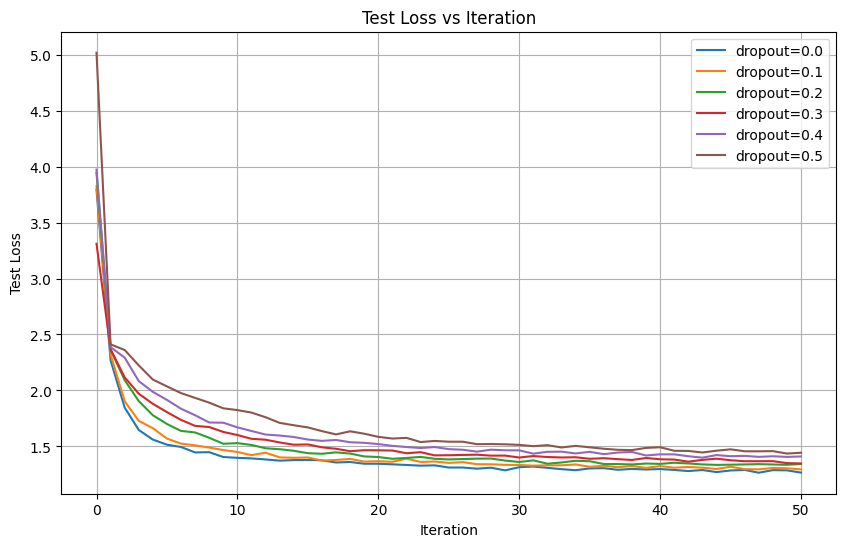

In [ ]:
# 1. Test Loss vs Iteration

plt.figure(figsize=(10,6))
for r in all_results:
    plt.plot(r['test_loss_history'], label=f"dropout={r['Dropout']}")

plt.xlabel("Iteration")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Iteration")
plt.legend()
plt.grid(True)
#plt.savefig(os.path.join(analysis_dir, "test_loss_vs_iteration.png"))
plt.show()

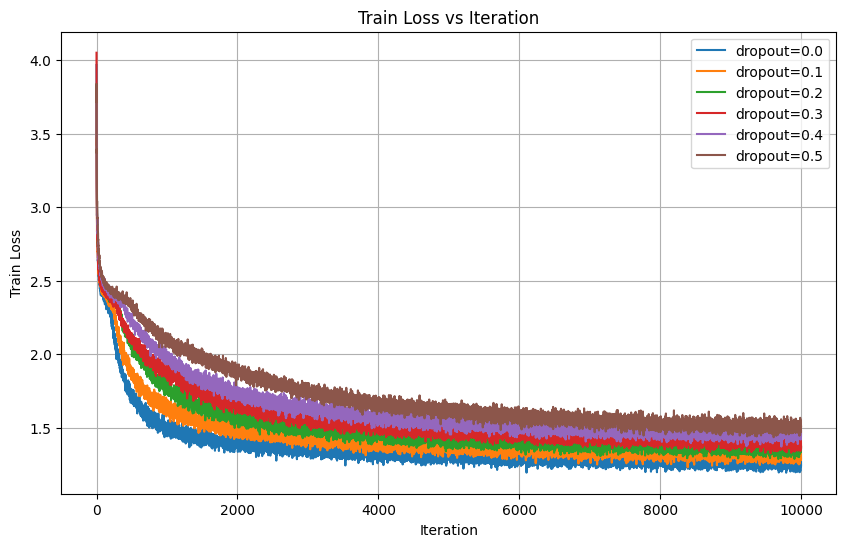

In [ ]:
# 2. Train Loss vs Iteration

plt.figure(figsize=(10,6))
for r in all_results:
    plt.plot(r['train_loss_history'], label=f"dropout={r['Dropout']}")

plt.xlabel("Iteration")
plt.ylabel("Train Loss")
plt.title("Train Loss vs Iteration")
plt.legend()
plt.grid(True)
#plt.savefig(os.path.join(analysis_dir, "train_loss_vs_iteration.png"))
plt.show()

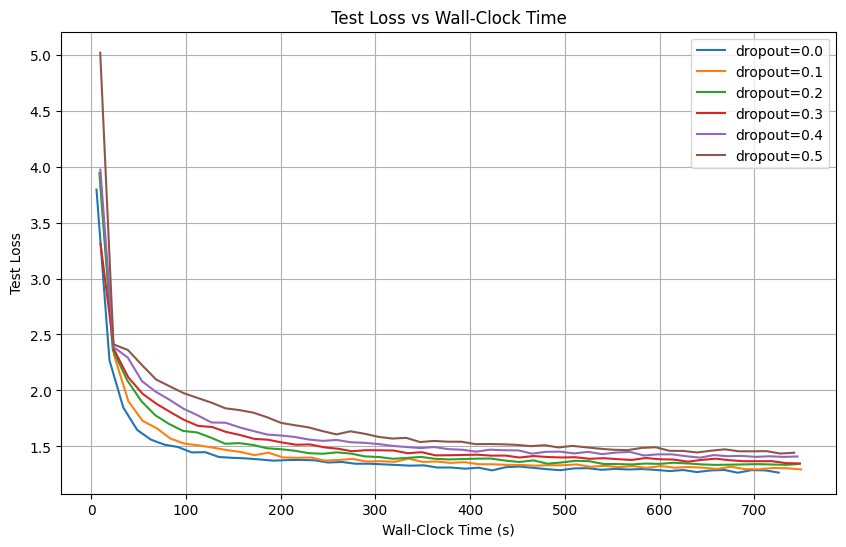

In [ ]:
# 3. Test Loss vs Wall-Clock Time

plt.figure(figsize=(10,6))
for r in all_results:
    times = r['test_time_history']
    plt.plot(times, r['test_loss_history'], label=f"dropout={r['Dropout']}")

plt.xlabel("Wall-Clock Time (s)")
plt.ylabel("Test Loss")
plt.title("Test Loss vs Wall-Clock Time")
plt.legend()
plt.grid(True)
#plt.savefig(os.path.join(analysis_dir, "test_loss_vs_time.png"))
plt.show()

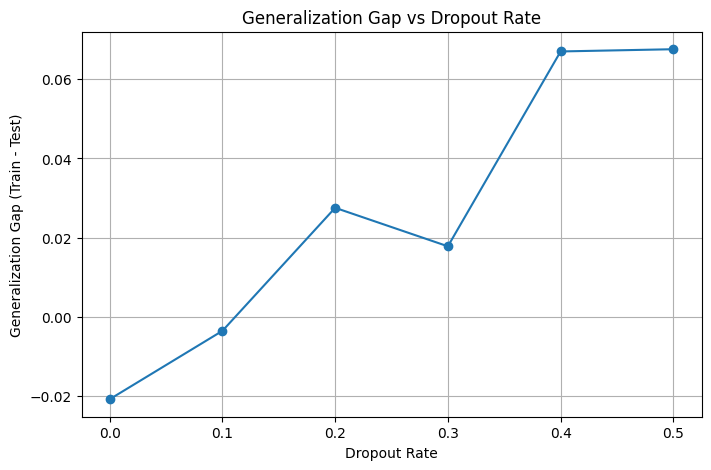

In [ ]:
# 5. Generalization Gap (Train - Test)

dropouts = [r['Dropout'] for r in all_results]
final_train_losses = [r['train_loss_history'][-1] for r in all_results]
final_test_losses = [r['test_loss_history'][-1] for r in all_results]
gaps = [train - test for train, test in zip(final_train_losses, final_test_losses)]

plt.figure(figsize=(8,5))
plt.plot(dropouts, gaps, marker='o')
plt.xlabel("Dropout Rate")
plt.ylabel("Generalization Gap (Train - Test)")
plt.title("Generalization Gap vs Dropout Rate")
plt.grid(True)
#plt.savefig(os.path.join(analysis_dir, "generalization_gap.png"))
plt.show()

In [ ]:
# Summary table
def generate_markdown_summary(results):
    # Sort results by dropout rate
    results_sorted = sorted(results, key=lambda x: x["Dropout"])

    markdown = []
    markdown.append("| Dropout | Final Train Loss | Final Test Loss | Gen. Gap (Train - Test) | Best Test Loss | Best Test Iter | Total Time (s) |")
    markdown.append("|---------|------------------|-----------------|-------------------------|----------------|----------------|----------------|")

    for r in results_sorted:
        dropout = r["Dropout"]
        train_loss = r["train_loss_history"][-1]
        test_loss = r["test_loss_history"][-1]
        gap = train_loss - test_loss

        # Best iteration for test loss
        best_iter = int(np.argmin(r["test_loss_history"]))
        best_test_loss = r["test_loss_history"][best_iter]

        total_time = r['test_time_history'][-1]

        markdown.append(
            f"| {dropout:.2f} | {train_loss:.4f} | {test_loss:.4f} | {gap:.4f} | {best_test_loss} | {best_iter} | {total_time:.2f} |"
        )

    return "\n".join(markdown)

# Generate & print the markdown table
markdown_table = generate_markdown_summary(all_results)
print(markdown_table)


| Dropout | Final Train Loss | Final Test Loss | Gen. Gap (Train - Test) | Best Test Loss | Best Test Iter | Total Time (s) |
|---------|------------------|-----------------|-------------------------|----------------|----------------|----------------|
| 0.00 | 1.2453 | 1.2660 | -0.0208 | 1.2649890184402466 | 47 | 725.82 |
| 0.10 | 1.2910 | 1.2945 | -0.0035 | 1.2945384979248047 | 50 | 749.46 |
| 0.20 | 1.3707 | 1.3431 | 0.0275 | 1.3350838422775269 | 44 | 747.88 |
| 0.30 | 1.3657 | 1.3479 | 0.0178 | 1.347898244857788 | 50 | 748.26 |
| 0.40 | 1.4774 | 1.4104 | 0.0670 | 1.399730920791626 | 43 | 745.72 |
| 0.50 | 1.5111 | 1.4436 | 0.0676 | 1.4362342357635498 | 49 | 742.22 |
